# Airport Analysis

### Import Libraries

In [15]:
# Import libraries
import networkx as nx
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community import asyn_lpa_communities
import pandas as pd
import matplotlib.pyplot as plt
import math
from collections import Counter

### Create Network Graph

In [16]:
# Convert csv as dataframe
df = pd.read_csv(
    "data/airline_network.csv",
    dtype={
        "Airline": "string",
        "Airline ID": "string",
        "Source airport": "string",
        "Source airport ID": "string",
        "Destination airport": "string",
        "Destination airport ID": "string",
        "Codeshare": "string",
        "Stops": "Int64",
        "Equipment": "string",
    },
    engine="python"
)

# Keep only wanted columns
df = df[["Source airport", "Destination airport", "Airline"]]

# Remove missing airports (NaN and '\N')
df = df[
    df["Source airport"].notna() &
    df["Destination airport"].notna() &
    (df["Source airport"] != r"\N") &
    (df["Destination airport"] != r"\N")
]

# Force strings
df["Source airport"] = df["Source airport"].astype(str)
df["Destination airport"] = df["Destination airport"].astype(str)

# Create empty multi-directed graph (parallel edges allowed)
G = nx.MultiDiGraph()

# Fill in graph object (one edge per route row)
for src, tgt, airline in df[["Source airport", "Destination airport", "Airline"]].itertuples(index=False, name=None):
    G.add_edge(src, tgt, Airline=airline)

# Display number of nodes and edges
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 3425
Edges: 67663


In [17]:
# Compress parallel edges into weighted edge
Gw = nx.DiGraph()
for u, v in G.edges():
    if Gw.has_edge(u, v):
        Gw[u][v]["weight"] += 1
    else:
        Gw.add_edge(u, v, weight=1)

print("Nodes:", Gw.number_of_nodes())
print("Unique/weighted edges:", Gw.number_of_edges())

Nodes: 3425
Unique/weighted edges: 37595


### Create CSV for Gephi

In [18]:
# Aggregate duplicate edges into Weight
edges_df = df.groupby(["Source airport", "Destination airport"]).size().reset_index(name="Weight")

# Rename for Gephi
edges_df = edges_df.rename(columns={"Source airport": "Source", "Destination airport": "Target"})

# Add edge type
edges_df["Type"] = "Directed"

# Reorder columns
edges_df = edges_df[["Source", "Target", "Type", "Weight"]]

# Save dataframe as csv
edges_df.to_csv("data/airport_edges.csv", index=False)
print(f"Saved airport_edges.csv with {len(edges_df)} edges")

Saved airport_edges.csv with 37595 edges


### Centrality

In [19]:
# Degree centrality unweighted (incoming + outgoing)
deg = nx.degree_centrality(G)

# Betweenness centrality weighted (approximated)
bet = nx.betweenness_centrality(Gw, k=200, normalized=True, seed=42) 

# Eigenvector centrality weighted (approximated)
eig = nx.eigenvector_centrality(Gw, max_iter=2000, tol=1e-6, weight="weight")

top_deg = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:10]
top_bet = sorted(bet.items(), key=lambda x: x[1], reverse=True)[:10]
top_eig = sorted(eig.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 Degree Centrality:")
for node, val in top_deg:
    print(node, val)

print("\nTop 10 Betweeness Centrality:")
for node, val in top_bet:
    print(node, val) 

print("\nTop 10 Eigenvector Centrality:")
for node, val in top_eig:
    print(node, val)

Top 10 Degree Centrality:
ATL 0.5332943925233644
ORD 0.3235981308411215
PEK 0.3122079439252336
LHR 0.3069509345794392
CDG 0.30403037383177567
LAX 0.2891355140186916
FRA 0.2891355140186916
DFW 0.2733644859813084
JFK 0.2660630841121495
AMS 0.26372663551401865

Top 10 Betweeness Centrality:
DXB 0.07105296332551136
CDG 0.06798971266990864
ANC 0.06049976573752198
FRA 0.05918287990106593
LAX 0.055636808117208024
SEA 0.0482532684241359
AMS 0.04748414220180165
ORD 0.04728099430334868
PEK 0.040651416760178055
YYZ 0.04062840853065042

Top 10 Eigenvector Centrality:
ATL 0.27029560703276984
LHR 0.20873457380630067
ORD 0.20063675607239673
JFK 0.19408557516160405
LAX 0.1885390214049639
CDG 0.15772032153678467
DFW 0.14525068009866365
FRA 0.14296788637554517
SFO 0.12624990143836815
YYZ 0.12518981180876557


In [20]:
n = len(deg)
top_k = math.ceil(0.10 * n)

# Top 10% by degree
top_deg_nodes = {
    node for node, _ in
    sorted(deg.items(),
           key=lambda x: x[1],
           reverse=True)[:top_k]
}

# Top 10% by betweenness
top_bet_nodes = {
    node for node, _ in
    sorted(bet.items(),
           key=lambda x: x[1],
           reverse=True)[:top_k]
}

# Intersection of degree and betweenness
overlap = top_deg_nodes & top_bet_nodes

print("Total nodes:", n)
print("Top 10% node count:", top_k)
print("Overlap count:", len(overlap))
print(f"Overlap percent: {len(overlap)/top_k * 100:.3f}%")

Total nodes: 3425
Top 10% node count: 343
Overlap count: 200
Overlap percent: 58.309%


### Community Detection

In [21]:
# Convert weighted graph to undirected
Gu = Gw.to_undirected()

print("Undirected Nodes:", Gu.number_of_nodes())
print("Undirected Edges:", Gu.number_of_edges())

Undirected Nodes: 3425
Undirected Edges: 19257


In [22]:
# Calculate Louvain comunity
louvain_comms = louvain_communities(Gu, weight="weight", resolution=1.0, seed=42)

print("Louvain communities:", len(louvain_comms))
print("Top 5 sizes:", sorted([len(c) for c in louvain_comms], reverse=True)[:5])

Louvain communities: 26
Top 5 sizes: [655, 575, 573, 383, 309]


In [23]:
# Calculate LPA community
lpa_comms = list(asyn_lpa_communities(G, weight="weight", seed=42))

print("LPA communities:", len(lpa_comms))
print("Top 5 sizes:", sorted([len(c) for c in lpa_comms], reverse=True)[:5])

LPA communities: 181
Top 5 sizes: [859, 635, 447, 132, 115]


### Degree Distribution

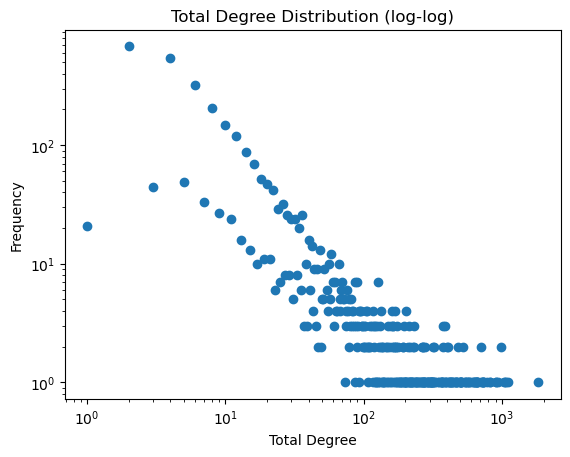

In [24]:
# Frequency of total degrees (in + out)
deg = [d for _, d in G.degree()]
deg_freq = Counter(deg)

# Sort degrees
tot_x = sorted(deg_freq.keys())  
tot_y = [deg_freq[k] for k in tot_x]

plt.figure()
plt.loglog(tot_x, tot_y, marker="o", linestyle="None")
plt.xlabel("Total Degree")
plt.ylabel("Frequency")
plt.title("Total Degree Distribution (log-log)")
plt.show()

### Diameter and Average Shortest Path

In [25]:
num_components = nx.number_strongly_connected_components(Gw)
largest_scc = max(nx.strongly_connected_components(Gw), key=len)
Gscc = Gw.subgraph(largest_scc).copy()

diam = nx.diameter(Gscc)
avg_len = nx.average_shortest_path_length(Gscc)

print("SCCs of Gw:", num_components)
print("Diameter (directed, on largest SCC):", diam)
print("Average shortest path (directed, on largest SCC):", avg_len)
print("Nodes in SCC:", Gscc.number_of_nodes())

SCCs of Gw: 44
Diameter (directed, on largest SCC): 14
Average shortest path (directed, on largest SCC): 4.125979351521906
Nodes in SCC: 3354
